## Model ProsusAI/FinBERT for Fraud Detection

**Approach:** FinBERT is a finance-domain BERT model trained on financial news text.
Since the credit card dataset is purely numerical, we convert each transaction row
into a natural language sentence and fine-tune FinBERT as a binary fraud classifier.

This is unconventional — and that's the point. We want to answer:
> *Does a finance-domain transformer outperform simple tabular models on fraud detection,
> and if so, is that performance gain worth the carbon cost?*

---
**Prerequisites:**
- Run `shared_baseline.ipynb` first — this notebook loads `splits/data_splits.pkl`
- Install dependencies: `pip install transformers torch scikit-learn pandas joblib`

**Notebook structure:**
1. Load Shared Data Splits
2. Sample the Dataset (practical consideration for transformer training)
3. Convert Transactions to Text
4. Tokenise for FinBERT
5. Fine-tune FinBERT
6. Evaluate Performance
7. Estimate Carbon Footprint
8. Save Summary

In [4]:
from google.colab import files
uploaded = files.upload()

Saving data_splits.pkl to data_splits.pkl


In [5]:
import os
os.makedirs('splits', exist_ok=True)
os.rename('data_splits.pkl', 'splits/data_splits.pkl')

In [6]:
!pip install transformers torch accelerate -q

In [1]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
import os
import warnings

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    PrecisionRecallDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Carbon constants — must match shared_baseline.ipynb
POWER_KW = 0.045
CARBON_INTENSITY = 0.233  # UK grid kg CO2/kWh

# Check GPU availability — FinBERT training on CPU is very slow
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('  ⚠ No GPU detected. Training will be slow — consider Google Colab (free GPU).')
else:
    print('  ✓ GPU available. Training will be much faster.')

Using device: cuda
  ✓ GPU available. Training will be much faster.


---
## Step 1 — Load Shared Data Splits

In [8]:
# This guarantees our results are directly comparable
X_train, X_test, y_train, y_test = joblib.load('splits/data_splits.pkl')

print('✓ Splits loaded from splits/data_splits.pkl')
print(f'  X_train: {X_train.shape}  |  Fraud in train: {y_train.sum()}')
print(f'  X_test:  {X_test.shape}   |  Fraud in test:  {y_test.sum()}')

✓ Splits loaded from splits/data_splits.pkl
  X_train: (226980, 30)  |  Fraud in train: 378
  X_test:  (56746, 30)   |  Fraud in test:  95


---
## Step 2 — Sample the Dataset

**Why we sample:**
FinBERT converts each row to text and tokenises it individually.

We use a **stratified sample** that preserves the fraud ratio.
We'll note the sample size in our results and carbon comparison.

In [21]:
SAMPLE_SIZE = 10_000  # reduced for time constraints

In [22]:
train_df = X_train.copy()
train_df['Class'] = y_train.values

fraud_df   = train_df[train_df['Class'] == 1]
genuine_df = train_df[train_df['Class'] == 0]

fraud_ratio = len(fraud_df) / len(train_df)
n_fraud     = max(int(SAMPLE_SIZE * fraud_ratio), 50)
n_genuine   = SAMPLE_SIZE - n_fraud

sample_df = pd.concat([
    fraud_df.sample(n=n_fraud, random_state=42),
    genuine_df.sample(n=n_genuine, random_state=42)
]).sample(frac=1, random_state=42)

X_train_sample = sample_df.drop(columns=['Class'])
y_train_sample = sample_df['Class']

print(f'Training sample: {len(sample_df):,} rows')
print(f'  Genuine: {(y_train_sample == 0).sum():,}  |  Fraud: {(y_train_sample == 1).sum():,}')
print(f'  Fraud ratio: {y_train_sample.mean()*100:.3f}%')
print(f'\nTest set: {len(X_test):,} rows (FULL)')

Training sample: 10,000 rows
  Genuine: 9,950  |  Fraud: 50
  Fraud ratio: 0.500%

Test set: 56,746 rows (FULL)


---
## Step 3 — Convert Transactions to Text

FinBERT expects natural language sentences. We describe each transaction
using its most discriminative features identified in EDA.

We focus on the top features by class separation: V17, V14, V12, V10, V16, V3, V7, V11.

In [23]:
def row_to_text(row):
    """
    Convert a transaction row into a natural language sentence for FinBERT.

    We include:
    - Amount and Time (the interpretable raw features)
    - Top V features by class separation from EDA

    We keep sentences concise — FinBERT has a 512 token limit.
    """
    return (
        f"Transaction amount {row['Amount_scaled']:.3f} at time {row['Time_scaled']:.3f}. "
        f"Risk indicators: "
        f"V17={row['V17']:.3f}, V14={row['V14']:.3f}, V12={row['V12']:.3f}, "
        f"V10={row['V10']:.3f}, V16={row['V16']:.3f}, V3={row['V3']:.3f}, "
        f"V7={row['V7']:.3f}, V11={row['V11']:.3f}."
    )

# Apply to training sample and full test set
print('Converting rows to text...')
train_texts = X_train_sample.apply(row_to_text, axis=1).tolist()
test_texts  = X_test.apply(row_to_text, axis=1).tolist()

print(f'\nExample sentence (genuine):')
print(f'  {train_texts[0]}')

# Find a fraud example
fraud_idx = y_train_sample[y_train_sample == 1].index[0]
fraud_pos = X_train_sample.index.get_loc(fraud_idx)
print(f'\nExample sentence (fraud):')
print(f'  {train_texts[fraud_pos]}')

Converting rows to text...

Example sentence (genuine):
  Transaction amount -0.172 at time 1.276. Risk indicators: V17=-0.891, V14=0.349, V12=-0.482, V10=0.801, V16=0.706, V3=0.686, V7=1.434, V11=-1.261.

Example sentence (fraud):
  Transaction amount -0.082 at time 0.709. Risk indicators: V17=-2.577, V14=-8.569, V12=-3.172, V10=-4.565, V16=-2.388, V3=-4.485, V7=-2.506, V11=3.613.


---
## Step 4 — Tokenise for FinBERT

In [24]:
# Load FinBERT tokenizer
# This downloads ~500MB on first run — subsequent runs use cache
print('Loading FinBERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
print('✓ Tokenizer loaded.')

# Check token length of our sentences — must be under 512
sample_tokens = tokenizer(train_texts[0], return_tensors='pt')
print(f'\nSample sentence token length: {sample_tokens["input_ids"].shape[1]}')
print('(Must be < 512 — we are fine.)')

Loading FinBERT tokenizer...
✓ Tokenizer loaded.

Sample sentence token length: 83
(Must be < 512 — we are fine.)


In [25]:
# PyTorch Dataset wrapper for FinBERT
class FraudDataset(Dataset):
    def __init__(self, texts, labels):
        # Tokenise all texts at once — padding to equal length, truncate if > 128
        # max_length=128 is sufficient for our short sentences and faster than 512
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128,
        )
        self.labels = list(labels)

    def __getitem__(self, idx):
        # Return a single tokenised item as tensors
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

print('Building datasets...')
train_dataset = FraudDataset(train_texts, y_train_sample.tolist())
test_dataset  = FraudDataset(test_texts, y_test.tolist())

print(f'✓ Train dataset: {len(train_dataset):,} items')
print(f'✓ Test dataset:  {len(test_dataset):,} items')

Building datasets...
✓ Train dataset: 10,000 items
✓ Test dataset:  56,746 items


---
## Step 5 — Fine-tune FinBERT

We replace FinBERT's original 3-class sentiment head with a 2-class fraud/genuine head.
The transformer weights are fine-tuned on our transaction text — the model adapts its
financial language understanding to the fraud detection task.

In [26]:
# Load FinBERT with a fresh binary classification head
# num_labels=2 replaces the 3-class sentiment head with fraud/genuine
print('Loading FinBERT model...')
model = BertForSequenceClassification.from_pretrained(
    'ProsusAI/finbert',
    num_labels=2,
    ignore_mismatched_sizes=True  # needed because we're changing the output head
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'✓ FinBERT loaded. Total parameters: {total_params:,}')
print(f'  (~110M parameters — compare to LR: ~30 parameters)')

Loading FinBERT model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✓ FinBERT loaded. Total parameters: 109,483,778
  (~110M parameters — compare to LR: ~30 parameters)


In [27]:
training_args = TrainingArguments(
    output_dir='./models/finbert_fraud',
    num_train_epochs=1,               # single pass to save time
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    warmup_steps=100,
    weight_decay=0.01,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print('Starting fine-tuning...')
print(f'Training on {len(train_dataset):,} samples for {training_args.num_train_epochs} epochs.')

train_start = time.time()
trainer.train()
train_time = time.time() - train_start

print(f'\n✓ Fine-tuning complete in {train_time:.1f} seconds ({train_time/60:.1f} minutes).')

Starting fine-tuning...
Training on 10,000 samples for 1 epochs.


Epoch,Training Loss,Validation Loss
1,0.011174,0.004856


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✓ Fine-tuning complete in 524.9 seconds (8.7 minutes).


---
## Step 6 — Evaluate Performance

In [28]:
# Get predictions on the full test set
print('Running predictions on test set...')
infer_start = time.time()
predictions = trainer.predict(test_dataset)
infer_time_full = time.time() - infer_start

# Convert raw logits to probabilities using softmax
logits = torch.tensor(predictions.predictions)
probs  = torch.softmax(logits, dim=1)[:, 1].numpy()  # probability of fraud
preds  = (probs > 0.5).astype(int)

print(f'✓ Predictions complete in {infer_time_full:.2f}s')

Running predictions on test set...


✓ Predictions complete in 285.04s


In [29]:
# Compute metrics
auc_roc = roc_auc_score(y_test, probs)
auprc   = average_precision_score(y_test, probs)
f1      = f1_score(y_test, preds)
prec    = precision_score(y_test, preds)
rec     = recall_score(y_test, preds)

print('FINBERT RESULTS:')
print(f'  AUC-ROC:          {auc_roc:.4f}')
print(f'  AUPRC (PRIMARY):  {auprc:.4f}')
print(f'  F1 Score:         {f1:.4f}')
print(f'  Precision:        {prec:.4f}')
print(f'  Recall:           {rec:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, preds, target_names=['Genuine', 'Fraud']))

FINBERT RESULTS:
  AUC-ROC:          0.9339
  AUPRC (PRIMARY):  0.5799
  F1 Score:         0.7219
  Precision:        0.8243
  Recall:           0.6421

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.82      0.64      0.72        95

    accuracy                           1.00     56746
   macro avg       0.91      0.82      0.86     56746
weighted avg       1.00      1.00      1.00     56746



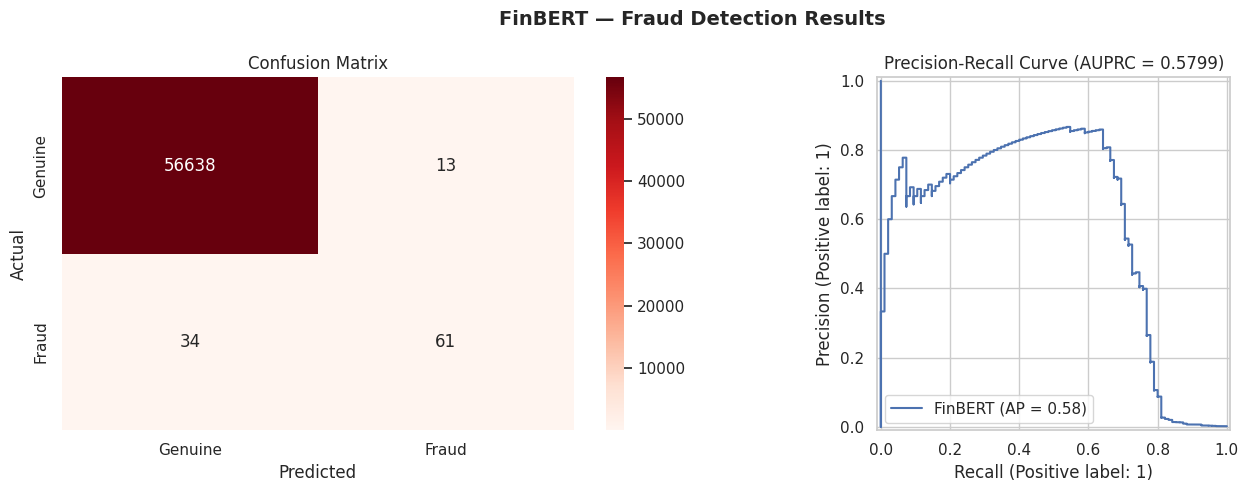

In [30]:
# Confusion matrix + Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FinBERT — Fraud Detection Results', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

PrecisionRecallDisplay.from_predictions(
    y_test, probs, ax=axes[1], name='FinBERT'
)
axes[1].set_title(f'Precision-Recall Curve (AUPRC = {auprc:.4f})')

plt.tight_layout()
plt.savefig('results/finbert_results.png', dpi=150)
plt.show()

---
## Step 7 — Estimate Carbon Footprint

In [31]:
# Carbon estimation using same formula as shared_baseline.ipynb
# If using a GPU, increase POWER_KW — a typical laptop GPU draws ~0.1-0.15 kW
if device.type == 'cuda':
    ACTUAL_POWER_KW = 0.15  # GPU draw
    print('GPU detected — using 0.15 kW power assumption.')
else:
    ACTUAL_POWER_KW = POWER_KW  # CPU draw
    print('CPU only — using 0.045 kW power assumption.')

# Training CO2
train_hours = train_time / 3600
kwh_train   = train_hours * ACTUAL_POWER_KW
co2_train   = kwh_train * CARBON_INTENSITY

# Inference CO2 per 1,000 predictions
# Scale from full test inference time
infer_per_1k = (infer_time_full / len(y_test)) * 1000  # seconds per 1k predictions
co2_infer    = (infer_per_1k / 3600) * ACTUAL_POWER_KW * CARBON_INTENSITY

print(f'\nEnvironmental Footprint:')
print(f'  Training time:              {train_time:.1f}s ({train_time/60:.1f} mins)')
print(f'  Training energy:            {kwh_train:.6f} kWh')
print(f'  Training CO2e:              {co2_train:.6f} kg')
print(f'  Inference CO2e (1k preds):  {co2_infer:.8f} kg')
print(f'\n  Note: trained on {len(train_dataset):,} samples (stratified sample of full training set).')
print(f'  At full scale ({len(X_train):,} samples), training CO2e would be ~{co2_train * len(X_train) / len(train_dataset):.4f} kg.')

GPU detected — using 0.15 kW power assumption.

Environmental Footprint:
  Training time:              524.9s (8.7 mins)
  Training energy:            0.021869 kWh
  Training CO2e:              0.005095 kg
  Inference CO2e (1k preds):  0.00004877 kg

  Note: trained on 10,000 samples (stratified sample of full training set).
  At full scale (226,980 samples), training CO2e would be ~0.1157 kg.


---
## Step 8 — Save Summary

In [33]:
# Save metrics in the same format
# comparison.ipynb will load all summary_*.json files

summary = {
    'model': 'ProsusAI/FinBERT (fine-tuned)',
    'auprc': round(float(auprc), 4),
    'auc_roc': round(float(auc_roc), 4),
    'f1': round(float(f1), 4),
    'precision': round(float(prec), 4),
    'recall': round(float(rec), 4),
    'train_time_s': round(train_time, 2),
    'train_samples': len(train_dataset),
    'co2_train_kg': round(co2_train, 8),
    'co2_infer_per_1k_kg': round(co2_infer, 10),
    'model_parameters': total_params,
    'notes': f'Trained on stratified sample of {len(train_dataset):,} rows. Evaluated on full test set.'
}

with open('results/summary_E_finbert.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save the fine-tuned model
trainer.save_model('models/finbert_fraud_final')

print('✓ results/summary_E_finbert.json saved')
print('✓ models/finbert_fraud_final/ saved')
print('\nFinal Summary:')
for k, v in summary.items():
    print(f'  {k:<35} {v}')

print('\n' + '='*60)
print('FINBERT NOTEBOOK COMPLETE.')
print('Push results/summary_E_finbert.json to the repo.')
print('='*60)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ results/summary_E_finbert.json saved
✓ models/finbert_fraud_final/ saved

Final Summary:
  model                               ProsusAI/FinBERT (fine-tuned)
  auprc                               0.5799
  auc_roc                             0.9339
  f1                                  0.7219
  precision                           0.8243
  recall                              0.6421
  train_time_s                        524.86
  train_samples                       10000
  co2_train_kg                        0.00509547
  co2_infer_per_1k_kg                 4.87665e-05
  model_parameters                    109483778
  notes                               Trained on stratified sample of 10,000 rows. Evaluated on full test set.

FINBERT NOTEBOOK COMPLETE.
Push results/summary_E_finbert.json to the repo.
